In [ ]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
  print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')

Saving 100_company_main.csv to 100_company_main.csv
User uploaded file "100_company_main.csv" with length 19586 bytes


Lineārā regresija


=== VIF (financial predictors) ===
        Variable        VIF
   log_MarketCap 371.923951
log_TotalRevenue 370.199581
      QuickRatio   7.010163
    CurrentRatio   4.847481
    DebtToEquity   3.680484
  ReturnOnEquity   3.494399


MODEL: Total_ESG (OLS, robust SE = HC3)
                            OLS Regression Results                            
Dep. Variable:              Total_ESG   R-squared:                       0.537
Model:                            OLS   Adj. R-squared:                  0.419
Method:                 Least Squares   F-statistic:                     28.72
Date:                Mon, 16 Feb 2026   Prob (F-statistic):           3.41e-28
Time:                        07:07:41   Log-Likelihood:                -283.42
No. Observations:                 100   AIC:                             608.8
Df Residuals:                      79   BIC:                             663.5
Df Model:                          20                                         
Covariance Type

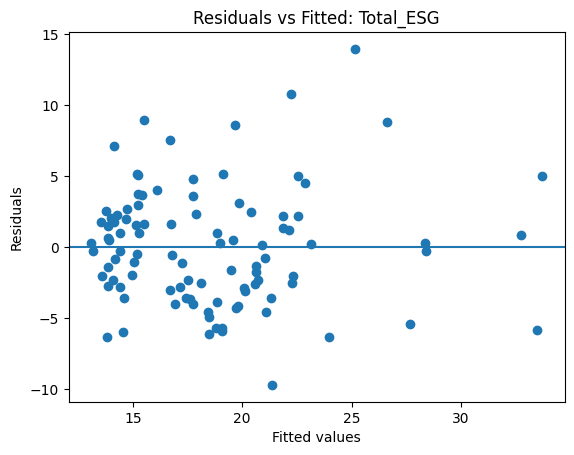

<Figure size 640x480 with 0 Axes>

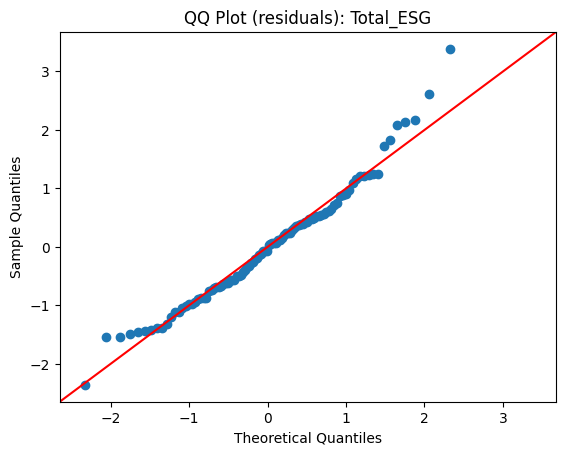

In [ ]:
import pandas as pd
import numpy as np

import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import statsmodels.api as sm

# -----------------------
# 1) Load data
# -----------------------
df = pd.read_csv("100_company_main.csv")

# -----------------------
# 2) Transformations
# -----------------------
df["log_MarketCap"] = np.log1p(df["MarketCap"])
df["log_TotalRevenue"] = np.log1p(df["TotalRevenue"])

# Optional: ensure categorical types (not required, but clean)
df["Sector"] = df["Sector"].astype("category")
df["Region"] = df["Region"].astype("category")

# -----------------------
# 3) VIF check (financial predictors only)
# -----------------------
X_vif = df[[
    "ReturnOnEquity",
    "DebtToEquity",
    "CurrentRatio",
    "QuickRatio",
    "log_MarketCap",
    "log_TotalRevenue"
]].copy()

# Drop any inf/nan just in case (you said no NA, but safe)
X_vif = X_vif.replace([np.inf, -np.inf], np.nan).dropna()

vif_table = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

print("\n=== VIF (financial predictors) ===")
print(vif_table.to_string(index=False))

# If VIF for CurrentRatio/QuickRatio is high, consider dropping one later.

# -----------------------
# 4) Define formulas (same RHS, different targets)
# -----------------------
rhs = """
ReturnOnEquity
+ DebtToEquity
+ CurrentRatio
+ QuickRatio
+ log_MarketCap
+ log_TotalRevenue
+ C(Sector)
+ C(Region)
"""

targets = ["Total_ESG", "Environmental", "Social", "Governance"]

models = {}

for y in targets:
    formula = f"{y} ~ {rhs}"
    # HC3 robust SE is often a good default for small samples / potential heteroskedasticity
    m = smf.ols(formula=formula, data=df).fit(cov_type="HC3")
    models[y] = m

    print(f"\n\n==============================")
    print(f"MODEL: {y} (OLS, robust SE = HC3)")
    print(f"==============================")
    print(m.summary())

# -----------------------
# 5) Compact comparison table (R2 / Adj R2 / F-stat)
# -----------------------
comp = pd.DataFrame({
    "Target": targets,
    "R2": [models[t].rsquared for t in targets],
    "Adj_R2": [models[t].rsquared_adj for t in targets],
    "N": [int(models[t].nobs) for t in targets],
    "F_stat": [models[t].fvalue for t in targets],
    "F_pvalue": [models[t].f_pvalue for t in targets]
}).sort_values("Adj_R2", ascending=False)

print("\n\n=== Model comparison (sorted by Adj_R2) ===")
print(comp.to_string(index=False))

# -----------------------
# 6) Diagnostics plots (example for Total_ESG; repeat if needed)
# -----------------------
def diagnostics_plots(model, title=""):
    fitted = model.fittedvalues
    resid = model.resid

    # Residuals vs Fitted
    plt.figure()
    plt.scatter(fitted, resid)
    plt.axhline(0)
    plt.xlabel("Fitted values")
    plt.ylabel("Residuals")
    plt.title(f"Residuals vs Fitted: {title}")
    plt.show()

    # QQ plot
    plt.figure()
    sm.qqplot(resid, line="45", fit=True)
    plt.title(f"QQ Plot (residuals): {title}")
    plt.show()

# Run diagnostics for Total_ESG (minimum recommended)
diagnostics_plots(models["Total_ESG"], title="Total_ESG")

# If you want, also run for E/S/G:
# diagnostics_plots(models["Environmental"], title="Environmental")
# diagnostics_plots(models["Social"], title="Social")
# diagnostics_plots(models["Governance"], title="Governance")

Atjauninātais modelis (bez Revenue)

In [ ]:
# VIF bez log_TotalRevenue
X_vif_reduced = df[[
    "ReturnOnEquity",
    "DebtToEquity",
    "CurrentRatio",
    "QuickRatio",
    "log_MarketCap"
]].copy()

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_reduced = pd.DataFrame({
    "Variable": X_vif_reduced.columns,
    "VIF": [variance_inflation_factor(X_vif_reduced.values, i)
            for i in range(X_vif_reduced.shape[1])]
}).sort_values("VIF", ascending=False)

print("\n=== VIF (reduced model) ===")
print(vif_reduced.to_string(index=False))



=== VIF (reduced model) ===
      Variable      VIF
    QuickRatio 6.994764
  CurrentRatio 4.830248
  DebtToEquity 3.507842
ReturnOnEquity 3.318906
 log_MarketCap 2.578797


In [ ]:
rhs_reduced = """
ReturnOnEquity
+ DebtToEquity
+ CurrentRatio
+ QuickRatio
+ log_MarketCap
+ C(Sector)
+ C(Region)
"""


In [ ]:
targets = ["Total_ESG", "Environmental", "Social", "Governance"]

models_reduced = {}

for y in targets:
    formula = f"{y} ~ {rhs_reduced}"
    m = smf.ols(formula=formula, data=df).fit(cov_type="HC3")
    models_reduced[y] = m

    print(f"\n\n==============================")
    print(f"REDUCED MODEL: {y}")
    print(f"==============================")
    print(m.summary())




REDUCED MODEL: Total_ESG
                            OLS Regression Results                            
Dep. Variable:              Total_ESG   R-squared:                       0.531
Model:                            OLS   Adj. R-squared:                  0.420
Method:                 Least Squares   F-statistic:                     43.25
Date:                Mon, 16 Feb 2026   Prob (F-statistic):           3.45e-34
Time:                        08:06:27   Log-Likelihood:                -283.97
No. Observations:                 100   AIC:                             607.9
Df Residuals:                      80   BIC:                             660.1
Df Model:                          19                                         
Covariance Type:                  HC3                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------

In [ ]:
comp_reduced = pd.DataFrame({
    "Target": targets,
    "R2": [models_reduced[t].rsquared for t in targets],
    "Adj_R2": [models_reduced[t].rsquared_adj for t in targets],
    "N": [int(models_reduced[t].nobs) for t in targets],
}).sort_values("Adj_R2", ascending=False)

print("\n\n=== Reduced model comparison ===")
print(comp_reduced.to_string(index=False))




=== Reduced model comparison ===
       Target       R2   Adj_R2   N
Environmental 0.703853 0.633518 100
   Governance 0.613045 0.521144 100
    Total_ESG 0.531341 0.420034 100
       Social 0.407293 0.266525 100


Vizualizācijas

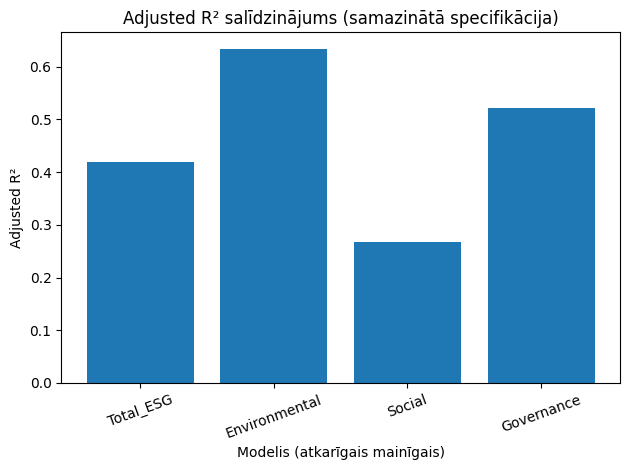

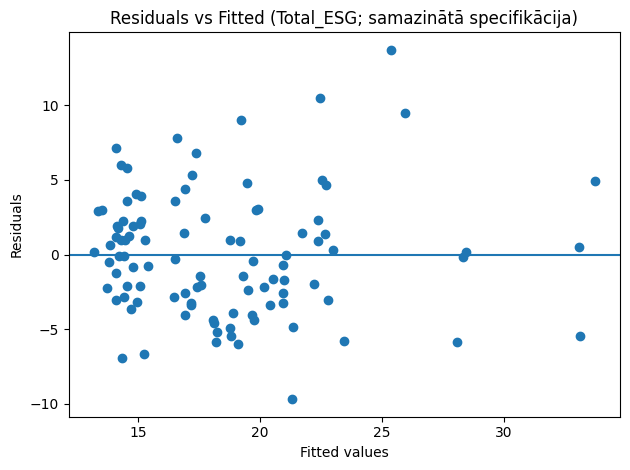

<Figure size 640x480 with 0 Axes>

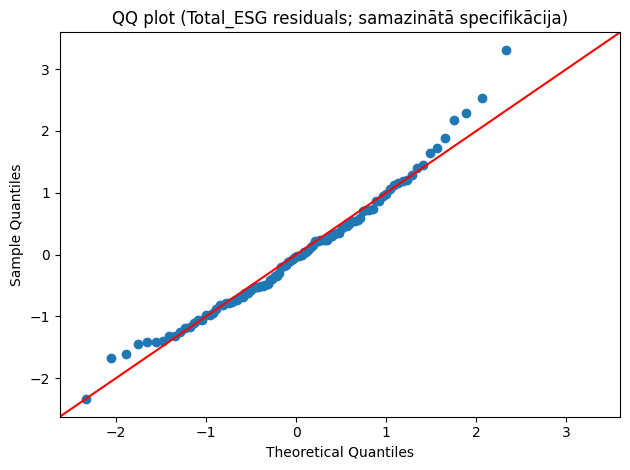

Saved figures to: regression_figures


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

DATA_FILE = "100_company_main.csv"
OUT_DIR = "regression_figures"
os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_csv(DATA_FILE)

df["log_MarketCap"] = np.log1p(df["MarketCap"])
df["Sector"] = df["Sector"].astype("category")
df["Region"] = df["Region"].astype("category")

rhs_reduced = """
ReturnOnEquity
+ DebtToEquity
+ CurrentRatio
+ QuickRatio
+ log_MarketCap
+ C(Sector)
+ C(Region)
"""

targets = ["Total_ESG", "Environmental", "Social", "Governance"]
models = {}

for y in targets:
    formula = f"{y} ~ {rhs_reduced}"
    models[y] = smf.ols(formula=formula, data=df).fit(cov_type="HC3")

comp = pd.DataFrame({
    "Target": targets,
    "R2": [models[t].rsquared for t in targets],
    "Adj_R2": [models[t].rsquared_adj for t in targets],
    "N": [int(models[t].nobs) for t in targets],
})
comp.to_csv(os.path.join(OUT_DIR, "model_comparison.csv"), index=False)

# Fig X: Adj R2 comparison
plt.figure()
plt.bar(comp["Target"], comp["Adj_R2"])
plt.xlabel("Modelis (atkarīgais mainīgais)")
plt.ylabel("Adjusted R²")
plt.title("Adjusted R² salīdzinājums (samazinātā specifikācija)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "fig_adjR2_comparison.png"), dpi=300)
plt.show() # Display the plot
plt.close() # Close the plot to free memory

# Diagnostics for Total_ESG
m = models["Total_ESG"]
fitted = m.fittedvalues
resid = m.resid

# Fig Y: Residuals vs Fitted
plt.figure()
plt.scatter(fitted, resid)
plt.axhline(0)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Total_ESG; samazinātā specifikācija)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "fig_residuals_vs_fitted_total_esg.png"), dpi=300)
plt.show() # Display the plot
plt.close() # Close the plot to free memory

# Fig Z: QQ plot
plt.figure()
sm.qqplot(resid, line="45", fit=True)
plt.title("QQ plot (Total_ESG residuals; samazinātā specifikācija)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "fig_qqplot_total_esg.png"), dpi=300)
plt.show() # Display the plot
plt.close() # Close the plot to free memory

print("Saved figures to:", OUT_DIR)

Papildus vizualizācijas

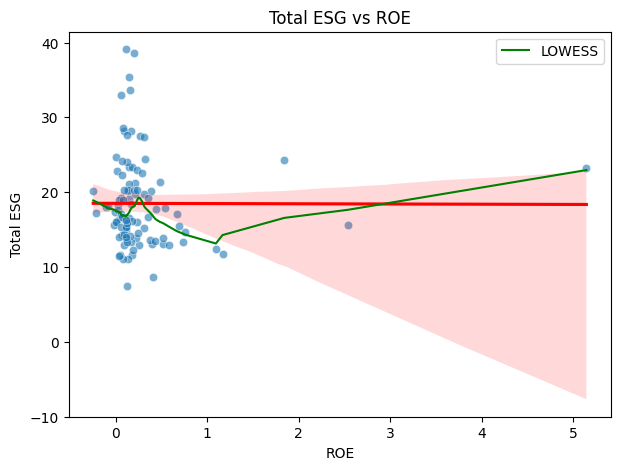

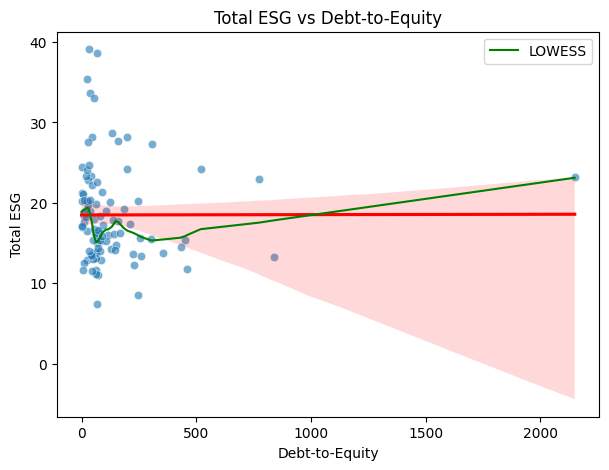

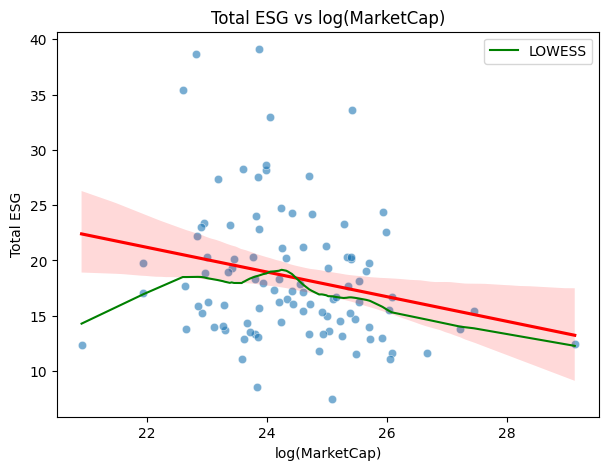

Functional form plots generated and saved as ESG_Functional_Form_Checks.pdf


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from matplotlib.backends.backend_pdf import PdfPages

# Load data
df = pd.read_csv("100_company_main.csv")

# Log transform
df["log_MarketCap"] = np.log(df["MarketCap"])

# Create PDF file
pdf = PdfPages("ESG_Functional_Form_Checks.pdf")

# Variables to test
variables = [
    ("ReturnOnEquity", "ROE"),
    ("DebtToEquity", "Debt-to-Equity"),
    ("log_MarketCap", "log(MarketCap)")
]

for var, label in variables:
    plt.figure(figsize=(7,5))

    # Scatter
    sns.scatterplot(x=df[var], y=df["Total_ESG"], alpha=0.6)

    # Linear regression line
    sns.regplot(x=df[var], y=df["Total_ESG"],
                scatter=False,
                color="red",
                line_kws={"label":"Linear fit"})

    # LOWESS curve
    lowess = sm.nonparametric.lowess(
        df["Total_ESG"],
        df[var],
        frac=0.4
    )
    plt.plot(lowess[:,0], lowess[:,1],
             color="green",
             label="LOWESS")

    plt.xlabel(label)
    plt.ylabel("Total ESG")
    plt.title(f"Total ESG vs {label}")
    plt.legend()

    # Save to PDF
    pdf.savefig()

    # Show in terminal
    plt.show()

pdf.close()

print("Functional form plots generated and saved as ESG_Functional_Form_Checks.pdf")


In [ ]:
dir()


['DATA_FILE',
 'In',
 'OUT_DIR',
 'Out',
 'PdfPages',
 'X_vif',
 'X_vif_reduced',
 '_',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '_dh',
 '_i',
 '_i1',
 '_i10',
 '_i11',
 '_i12',
 '_i13',
 '_i2',
 '_i3',
 '_i4',
 '_i5',
 '_i6',
 '_i7',
 '_i8',
 '_i9',
 '_ih',
 '_ii',
 '_iii',
 '_oh',
 'comp',
 'comp_reduced',
 'df',
 'diagnostics_plots',
 'exit',
 'filename',
 'files',
 'fitted',
 'formula',
 'get_ipython',
 'label',
 'lowess',
 'm',
 'models',
 'models_reduced',
 'np',
 'os',
 'pd',
 'pdf',
 'plt',
 'quit',
 'resid',
 'rhs',
 'rhs_reduced',
 'sm',
 'smf',
 'sns',
 'targets',
 'uploaded',
 'var',
 'variables',
 'variance_inflation_factor',
 'vif_reduced',
 'vif_table',
 'y']

In [ ]:
import pandas as pd
import numpy as np

# Ņemam samazināto specifikāciju
models_dict = models_reduced  # <- Tavs objekts no dir()

# Finanšu mainīgie reduced modelī
financial_vars = [
    "ReturnOnEquity",
    "DebtToEquity",
    "CurrentRatio",
    "QuickRatio",
    "log_MarketCap"
]

def signif_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

rows = []

# models_reduced ir dict: {"Total_ESG": model, "Environmental": model, ...}
for target, model in models_dict.items():
    for var in financial_vars:
        if var in model.params.index:
            coef = model.params[var]
            pval = model.pvalues[var]
            rows.append({
                "Target": target,
                "Variable": var,
                "Coef": coef,
                "p_value": pval,
                "Sig": signif_stars(pval),
                "Coef_fmt": f"{coef:.4f}{signif_stars(pval)}",
                "p_fmt": f"{pval:.4f}"
            })

long_df = pd.DataFrame(rows)

# Pivot: kompakts formāts darbam (koef + p katram mērķim)
coef_table = long_df.pivot(index="Variable", columns="Target", values="Coef_fmt")
p_table    = long_df.pivot(index="Variable", columns="Target", values="p_fmt")

# Sakārtojam kolonnu secību
col_order = ["Total_ESG", "Environmental", "Social", "Governance"]
coef_table = coef_table.reindex(columns=[c for c in col_order if c in coef_table.columns])
p_table    = p_table.reindex(columns=[c for c in col_order if c in p_table.columns])

print("\n=== Financial predictors: coefficients (with significance stars) ===\n")
print(coef_table)

print("\n=== Financial predictors: p-values ===\n")
print(p_table)

# Saglabājam CSV (2 failus — tīri un ērti darbam)
coef_table.to_csv("reg_financial_coef_table.csv")
p_table.to_csv("reg_financial_pvalue_table.csv")

# (Neobligāti) Excel vienā failā ar 2 lapām
with pd.ExcelWriter("reg_financial_summary_tables.xlsx") as writer:
    coef_table.to_excel(writer, sheet_name="coef_with_stars")
    p_table.to_excel(writer, sheet_name="p_values")

print("\nSaved:")
print(" - reg_financial_coef_table.csv")
print(" - reg_financial_pvalue_table.csv")
print(" - reg_financial_summary_tables.xlsx")



=== Financial predictors: coefficients (with significance stars) ===

Target         Total_ESG Environmental   Social Governance
Variable                                                  
CurrentRatio     -0.1090        0.0381  -0.0111    -0.1357
DebtToEquity     -0.0016       -0.0000  -0.0017     0.0002
QuickRatio       -0.0776       -0.2551  -0.0479     0.2242
ReturnOnEquity    0.9996        0.6730   0.2179     0.1062
log_MarketCap    -0.2255       -0.3955   0.0864     0.0843

=== Financial predictors: p-values ===

Target         Total_ESG Environmental  Social Governance
Variable                                                 
CurrentRatio      0.7780        0.9359  0.9641     0.3895
DebtToEquity      0.6728        0.9869  0.2829     0.9220
QuickRatio        0.9358        0.6949  0.9199     0.6358
ReturnOnEquity    0.5011        0.4898  0.7415     0.8563
log_MarketCap     0.6484        0.1916  0.7600     0.6725

Saved:
 - reg_financial_coef_table.csv
 - reg_financial_pvalue_table

In [ ]:
import pandas as pd
import numpy as np

models_dict = models_reduced  # Tavs reduced modeļu dict

financial_vars = [
    "ReturnOnEquity",
    "DebtToEquity",
    "CurrentRatio",
    "QuickRatio",
    "log_MarketCap"
]

def signif_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

rows = []

for target, model in models_dict.items():
    for var in financial_vars:
        if var in model.params.index:
            coef = model.params[var]
            pval = model.pvalues[var]
            stars = signif_stars(pval)

            formatted = f"{coef:.4f}{stars} ({pval:.4f})"

            rows.append({
                "Variable": var,
                "Target": target,
                "Result": formatted
            })

long_df = pd.DataFrame(rows)

# Pivotējam žurnālu stilā
journal_table = long_df.pivot(index="Variable",
                              columns="Target",
                              values="Result")

# Sakārtojam kolonnu secību
col_order = ["Total_ESG", "Environmental", "Social", "Governance"]
journal_table = journal_table.reindex(columns=[c for c in col_order if c in journal_table.columns])

print("\n=== Journal Style Regression Table ===\n")
print(journal_table)

# Saglabāšana
journal_table.to_csv("regression_journal_style_table.csv")

with pd.ExcelWriter("regression_journal_style_table.xlsx") as writer:
    journal_table.to_excel(writer, sheet_name="Regression")

print("\nSaved:")
print(" - regression_journal_style_table.csv")
print(" - regression_journal_style_table.xlsx")



=== Journal Style Regression Table ===

Target                 Total_ESG     Environmental            Social  \
Variable                                                               
CurrentRatio    -0.1090 (0.7780)   0.0381 (0.9359)  -0.0111 (0.9641)   
DebtToEquity    -0.0016 (0.6728)  -0.0000 (0.9869)  -0.0017 (0.2829)   
QuickRatio      -0.0776 (0.9358)  -0.2551 (0.6949)  -0.0479 (0.9199)   
ReturnOnEquity   0.9996 (0.5011)   0.6730 (0.4898)   0.2179 (0.7415)   
log_MarketCap   -0.2255 (0.6484)  -0.3955 (0.1916)   0.0864 (0.7600)   

Target                Governance  
Variable                          
CurrentRatio    -0.1357 (0.3895)  
DebtToEquity     0.0002 (0.9220)  
QuickRatio       0.2242 (0.6358)  
ReturnOnEquity   0.1062 (0.8563)  
log_MarketCap    0.0843 (0.6725)  

Saved:
 - regression_journal_style_table.csv
 - regression_journal_style_table.xlsx


Random Forest

In [16]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
  print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')

TypeError: 'NoneType' object is not subscriptable

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# --- Load data and perform transformations (repeated for self-containment) ---
df = pd.read_csv("100_company_main.csv")
df["log_MarketCap"] = np.log1p(df["MarketCap"])
df["Sector"] = df["Sector"].astype("category")
df["Region"] = df["Region"].astype("category")
# ---------------------------------------------------------------------------

# ===== 1. Definējam mainīgos =====

numeric_features = [
    "ReturnOnEquity",
    "DebtToEquity",
    "CurrentRatio",
    "QuickRatio",
    "log_MarketCap"
]

categorical_features = ["Sector", "Region"]

targets = ["Total_ESG", "Environmental", "Social", "Governance"]

X = df[numeric_features + categorical_features]

# ===== 2. Preprocessing (One-Hot Encoding kategorijām) =====

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ]
)

# ===== 3. Random Forest modelis =====

rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    random_state=42
)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", rf_model)
])

# ===== 4. Cross-validation =====

kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for target in targets:

    y = df[target]

    scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=kf,
        scoring="r2"
    )

    results[target] = {
        "Mean_R2": np.mean(scores),
        "Std_R2": np.std(scores)
    }

# ===== 5. Izvadām R² rezultātus =====

rf_r2_table = pd.DataFrame(results).T.round(4)

print("\n=== Random Forest Cross-Validated R² ===\n")
print(rf_r2_table)


=== Random Forest Cross-Validated R² ===

               Mean_R2  Std_R2
Total_ESG       0.1686  0.1856
Environmental   0.2112  0.1311
Social         -0.0091  0.2086
Governance      0.1866  0.4997


In [ ]:
feature_importance_results = {}

for target in targets:

    y = df[target]
    pipeline.fit(X, y)

    # Iegūstam feature names pēc one-hot
    ohe = pipeline.named_steps["preprocessor"].named_transformers_["cat"]
    cat_names = ohe.get_feature_names_out(categorical_features)

    feature_names = numeric_features + list(cat_names)

    importances = pipeline.named_steps["model"].feature_importances_

    fi_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    feature_importance_results[target] = fi_df

    print(f"\n=== Feature Importance: {target} ===\n")
    print(fi_df.head(10))


=== Feature Importance: Total_ESG ===

                     Feature  Importance
1               DebtToEquity    0.219729
8              Sector_Energy    0.168126
4              log_MarketCap    0.142574
0             ReturnOnEquity    0.091562
2               CurrentRatio    0.085748
3                 QuickRatio    0.064737
14          Sector_Utilities    0.056571
11        Sector_Industrials    0.053814
15       Region_Asia-Pacific    0.027317
6   Sector_Consumer Cyclical    0.019547

=== Feature Importance: Environmental ===

                      Feature  Importance
8               Sector_Energy    0.178211
4               log_MarketCap    0.130995
0              ReturnOnEquity    0.122069
3                  QuickRatio    0.108146
1                DebtToEquity    0.090245
9   Sector_Financial Services    0.067575
2                CurrentRatio    0.066121
10          Sector_Healthcare    0.055590
14           Sector_Utilities    0.044572
6    Sector_Consumer Cyclical    0.022688

==

In [ ]:
from sklearn.metrics import r2_score

overfit_results = {}

for target in targets:

    y = df[target]

    # Fit uz VISIEM datiem
    pipeline.fit(X, y)

    # Train R²
    y_pred_train = pipeline.predict(X)
    train_r2 = r2_score(y, y_pred_train)

    # Cross-validated R²
    cv_scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=kf,
        scoring="r2"
    )

    overfit_results[target] = {
        "Train_R2": train_r2,
        "CV_Mean_R2": np.mean(cv_scores),
        "CV_Std": np.std(cv_scores)
    }

overfit_table = pd.DataFrame(overfit_results).T.round(4)

print("\n=== Overfitting Check ===\n")
print(overfit_table)


=== Overfitting Check ===

               Train_R2  CV_Mean_R2  CV_Std
Total_ESG        0.8933      0.1686  0.1856
Environmental    0.8992      0.2112  0.1311
Social           0.8900     -0.0091  0.2086
Governance       0.9147      0.1866  0.4997


Rubustness check - 512 companies

In [ ]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
  print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')

Saving acwi_552_with_yahoo_names.csv to acwi_552_with_yahoo_names.csv
User uploaded file "acwi_552_with_yahoo_names.csv" with length 110329 bytes


In [ ]:
import pandas as pd

acwi_552_with_yahoo_names = pd.read_csv('acwi_552_with_yahoo_names.csv')
display(acwi_552_with_yahoo_names.head())


,Ticker,Total_ESG,Environmental,Social,Governance,Sum_sub,Diff,Anomaly,Country,Sector,Industry,MarketCap,TotalRevenue,NetIncome,ReturnOnEquity,DebtToEquity,CurrentRatio,QuickRatio,Region,Yahoo_Finance_Name
0,NVDA,12.45,3.50,4.08,4.87,12.45,0.00,False,United States,Technology,Semiconductors,4460857262080,165217992704,86597001216,1.09417,10.584,4.214,3.488,North America,NVIDIA Corporation
1,AAPL,14.19,2.40,7.37,4.42,14.19,0.00,False,United States,Technology,Consumer Electronics,3744081903616,408624988160,99280003072,1.49814,154.486,0.868,0.724,North America,Apple Inc.
2,MSFT,13.43,3.25,6.99,3.18,13.42,0.01,False,United States,Technology,Software - Infrastructure,3817525739520,281723994112,101831999488,0.33281,32.661,1.353,1.223,North America,Microsoft Corporation
3,AMZN,18.37,7.82,5.75,4.80,18.37,0.00,False,United States,Consumer Cyclical,Internet Retail,2272052641792,670038032384,70623002624,0.24770,47.808,1.024,0.768,North America,"Amazon.com, Inc."
4,AVGO,17.83,8.10,6.86,2.86,17.82,0.01,False,United States,Technology,Semiconductors,1649663672320,59925999616,18812999680,0.27083,166.032,1.497,1.279,North America,Broadcom Inc.


In [ ]:
print('\nVispārīga informācija par acwi_552_with_yahoo_names:')
print(acwi_552_with_yahoo_names.info())



Vispārīga informācija par acwi_552_with_yahoo_names:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 552 entries, 0 to 551
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Ticker              552 non-null    object 
 1   Total_ESG           552 non-null    float64
 2   Environmental       552 non-null    float64
 3   Social              552 non-null    float64
 4   Governance          552 non-null    float64
 5   Sum_sub             552 non-null    float64
 6   Diff                552 non-null    float64
 7   Anomaly             552 non-null    bool   
 8   Country             552 non-null    object 
 9   Sector              552 non-null    object 
 10  Industry            552 non-null    object 
 11  MarketCap           552 non-null    int64  
 12  TotalRevenue        552 non-null    int64  
 13  NetIncome           552 non-null    int64  
 14  ReturnOnEquity      552 non-null    float64
 15  Deb

In [ ]:
df_552 = pd.read_csv("acwi_552_with_yahoo_names.csv")

print(df_552.shape)
print(df_552.isna().sum())
print((df_552["MarketCap"] <= 0).sum())

(552, 20)
Ticker                0
Total_ESG             0
Environmental         0
Social                0
Governance            0
Sum_sub               0
Diff                  0
Anomaly               0
Country               0
Sector                0
Industry              0
MarketCap             0
TotalRevenue          0
NetIncome             0
ReturnOnEquity        0
DebtToEquity          0
CurrentRatio          0
QuickRatio            0
Region                0
Yahoo_Finance_Name    3
dtype: int64
0


In [ ]:
df_552["log_MarketCap"] = np.log(df_552["MarketCap"])

In [ ]:
numeric_features = [
    "ReturnOnEquity",
    "DebtToEquity",
    "CurrentRatio",
    "QuickRatio",
    "log_MarketCap"
]

categorical_features = ["Sector", "Region"]

targets = ["Total_ESG", "Environmental", "Social", "Governance"]

X_552 = df_552[numeric_features + categorical_features]

In [ ]:
results_552 = {}

for target in targets:

    y = df_552[target]

    scores = cross_val_score(
        pipeline,
        X_552,
        y,
        cv=kf,
        scoring="r2"
    )

    results_552[target] = {
        "Mean_R2": np.mean(scores),
        "Std_R2": np.std(scores)
    }

rf_r2_552 = pd.DataFrame(results_552).T.round(4)

print("\n=== RF (N=552) Cross-Validated R² ===\n")
print(rf_r2_552)


=== RF (N=552) Cross-Validated R² ===

               Mean_R2  Std_R2
Total_ESG       0.3699  0.0948
Environmental   0.5289  0.0727
Social          0.2272  0.0752
Governance      0.4027  0.0641


In [ ]:
overfit_552 = {}

for target in targets:

    y = df_552[target]

    pipeline.fit(X_552, y)

    train_r2 = pipeline.score(X_552, y)

    cv_scores = cross_val_score(
        pipeline,
        X_552,
        y,
        cv=kf,
        scoring="r2"
    )

    overfit_552[target] = {
        "Train_R2": train_r2,
        "CV_Mean_R2": np.mean(cv_scores),
        "CV_Std": np.std(cv_scores)
    }

overfit_table_552 = pd.DataFrame(overfit_552).T.round(4)

print("\n=== Overfitting Check (N=552) ===\n")
print(overfit_table_552)


=== Overfitting Check (N=552) ===

               Train_R2  CV_Mean_R2  CV_Std
Total_ESG        0.9149      0.3699  0.0948
Environmental    0.9402      0.5289  0.0727
Social           0.8945      0.2272  0.0752
Governance       0.9243      0.4027  0.0641


In [ ]:
feature_importance_552 = {}

for target in targets:

    y = df_552[target]
    pipeline.fit(X_552, y)

    ohe = pipeline.named_steps["preprocessor"].named_transformers_["cat"]
    cat_names = ohe.get_feature_names_out(categorical_features)

    feature_names = numeric_features + list(cat_names)

    importances = pipeline.named_steps["model"].feature_importances_

    fi_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    feature_importance_552[target] = fi_df

    print(f"\n=== Feature Importance (N=552): {target} ===\n")
    print(fi_df.head(10))


=== Feature Importance (N=552): Total_ESG ===

               Feature  Importance
8        Sector_Energy    0.168189
1         DebtToEquity    0.157674
0       ReturnOnEquity    0.127259
4        log_MarketCap    0.122987
2         CurrentRatio    0.101953
3           QuickRatio    0.090494
12  Sector_Real Estate    0.054098
13   Sector_Technology    0.044225
14    Sector_Utilities    0.024279
11  Sector_Industrials    0.023568

=== Feature Importance (N=552): Environmental ===

                          Feature  Importance
8                   Sector_Energy    0.232862
1                    DebtToEquity    0.119282
0                  ReturnOnEquity    0.083215
3                      QuickRatio    0.081586
2                    CurrentRatio    0.077443
4                   log_MarketCap    0.068033
9       Sector_Financial Services    0.063936
10              Sector_Healthcare    0.053546
13              Sector_Technology    0.042493
5   Sector_Communication Services    0.040403

=== Feat

In [ ]:
import statsmodels.formula.api as smf

formula_reduced = """
{target} ~ ReturnOnEquity
+ DebtToEquity
+ CurrentRatio
+ QuickRatio
+ log_MarketCap
+ C(Sector)
+ C(Region)
"""

ols_results_552 = {}

for target in targets:

    model = smf.ols(
        formula=formula_reduced.format(target=target),
        data=df_552
    ).fit(cov_type="HC3")

    ols_results_552[target] = {
        "R2": model.rsquared,
        "Adj_R2": model.rsquared_adj
    }

ols_table_552 = pd.DataFrame(ols_results_552).T.round(4)

print("\n=== OLS (N=552) Results ===\n")
print(ols_table_552)


=== OLS (N=552) Results ===

                   R2  Adj_R2
Total_ESG      0.4019  0.3805
Environmental  0.5774  0.5623
Social         0.2964  0.2712
Governance     0.4568  0.4374


Salīdzinājuma tabula: Linear Regression (100) vs RF (100 & 552)

In [21]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf # Added import

# Define rhs_reduced (from cell TmU_JRxvfCIV) as it's a prerequisite for models_reduced
rhs_reduced = """
ReturnOnEquity
+ DebtToEquity
+ CurrentRatio
+ QuickRatio
+ log_MarketCap
+ C(Sector)
+ C(Region)
"""

# Define models_reduced (from cell HgcZk9bWfFGa) as it was not executed
# Assuming 'targets' and 'df' are already available in the kernel state from previous executions
models_reduced = {}

for y in targets:
    formula = f"{y} ~ {rhs_reduced}"
    m = smf.ols(formula=formula, data=df).fit(cov_type="HC3")
    models_reduced[y] = m

# Re-create comp_reduced as it was not executed prior
comp_reduced = pd.DataFrame({
    "Target": targets,
    "R2": [models_reduced[t].rsquared for t in targets],
    "Adj_R2": [models_reduced[t].rsquared_adj for t in targets],
    "N": [int(models_reduced[t].nobs) for t in targets],
}).sort_values("Adj_R2", ascending=False)

# 1. Linear Regression (100 companies) - from 'comp_reduced'
# We'll use Adjusted R2 as the primary metric for OLS
ols_100_results = comp_reduced[['Target', 'Adj_R2']].set_index('Target')
ols_100_results.columns = ['OLS_100_Adj_R2']

# 2. Random Forest (100 companies) - from 'rf_r2_table'
# We'll use Mean_R2 as the primary metric for RF
rf_100_results = rf_r2_table[['Mean_R2']].copy()
rf_100_results.columns = ['RF_100_Mean_R2']

# 3. Random Forest (552 companies) - from 'rf_r2_552'
rf_552_results = rf_r2_552[['Mean_R2']].copy()
rf_552_results.columns = ['RF_552_Mean_R2']

# 4. OLS (552 companies) - from 'ols_table_552' (just to have it in the same table context if needed)
ols_552_results = ols_table_552[['Adj_R2']].copy()
ols_552_results.columns = ['OLS_552_Adj_R2']

# Combine all results into one DataFrame
comparison_table = pd.concat([ols_100_results, rf_100_results, ols_552_results, rf_552_results], axis=1)

# Reorder columns for better comparison: OLS_100, RF_100, OLS_552, RF_552
comparison_table = comparison_table[['OLS_100_Adj_R2', 'RF_100_Mean_R2', 'OLS_552_Adj_R2', 'RF_552_Mean_R2']]

# Display the comparison table
print("\n=== Model Results Comparison (R-squared) ===\n")
print(comparison_table.to_string())

# Optional: Save to CSV or Excel
comparison_table.to_csv("model_comparison_r2.csv")
with pd.ExcelWriter("model_comparison_r2.xlsx") as writer:
    comparison_table.to_excel(writer, sheet_name="R2 Comparison")

print("\nSaved: model_comparison_r2.csv and model_comparison_r2.xlsx")


=== Model Results Comparison (R-squared) ===

               OLS_100_Adj_R2  RF_100_Mean_R2  OLS_552_Adj_R2  RF_552_Mean_R2
Environmental        0.633518          0.2112          0.5623          0.5289
Governance           0.521144          0.1866          0.4374          0.4027
Total_ESG            0.420034          0.1686          0.3805          0.3699
Social               0.266525         -0.0091          0.2712          0.2272

Saved: model_comparison_r2.csv and model_comparison_r2.xlsx
